## Yêu cầu
Dựa trên đoạn code CNN đã cung cấp (phân loại MNIST), hãy thực hiện các nhiệm vụ sau. Gửi lại code hoàn chỉnh kèm giải thích ngắn gọn cho từng câu hỏi trong file Jupyter Notebook.

### Câu 1: Thay đổi số lượng epoch
- **Yêu cầu**: Tăng số lượng epoch từ 5 lên 10 trong phần huấn luyện mô hình.
- **Hướng dẫn**: Tìm dòng `for epoch in range(5):` và sửa thành `for epoch in range(10):`. Chạy lại code và ghi nhận:
  - Độ chính xác trên tập test có thay đổi không? Nếu có, tăng hay giảm?
  - Biểu đồ mất mát (loss) thay đổi thế nào qua 10 epoch? Có xu hướng nào đáng chú ý không (ví dụ: giảm đều, chững lại)?
-  Giải thích về lý do tại sao số epoch ảnh hưởng đến kết quả.

100.0%
100.0%
100.0%
100.0%


Epoch 1/10  Loss: 0.2910  Accuracy: 90.99%
Epoch 2/10  Loss: 0.0850  Accuracy: 97.42%
Epoch 3/10  Loss: 0.0662  Accuracy: 97.97%
Epoch 4/10  Loss: 0.0544  Accuracy: 98.30%
Epoch 5/10  Loss: 0.0490  Accuracy: 98.50%
Epoch 6/10  Loss: 0.0436  Accuracy: 98.62%
Epoch 7/10  Loss: 0.0396  Accuracy: 98.79%
Epoch 8/10  Loss: 0.0376  Accuracy: 98.84%
Epoch 9/10  Loss: 0.0346  Accuracy: 98.90%
Epoch 10/10  Loss: 0.0314  Accuracy: 99.01%


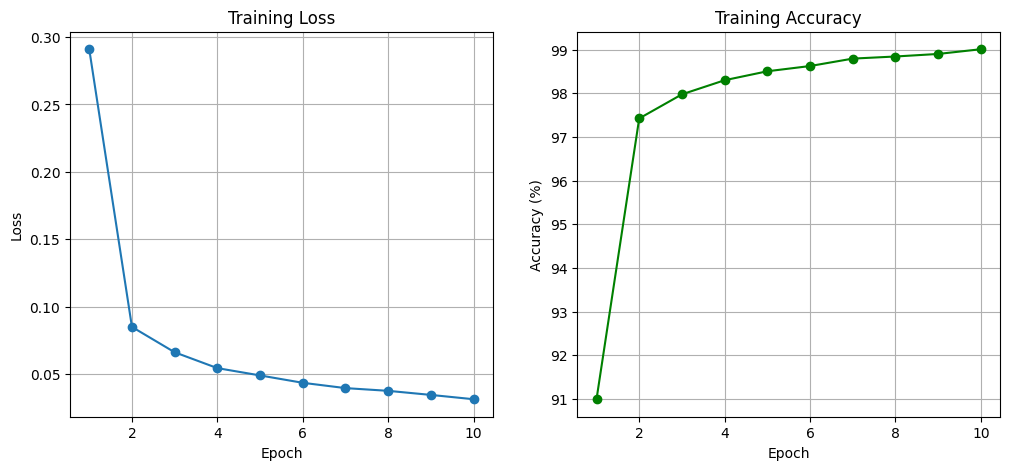


Test Accuracy: 98.61%


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# 1. Load dataset MNIST
# ===============================

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# ===============================
# 2. Define CNN model
# ===============================

class MNIST_CNN(nn.Module):

    def __init__(self):
        super(MNIST_CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(32*5*5,10)

    def forward(self, x):

        x = self.pool(torch.relu(self.conv1(x)))

        x = self.pool(torch.relu(self.conv2(x)))

        x = x.view(-1, 32*5*5)

        x = self.fc1(x)

        return x


# ===============================
# 3. Initialize model
# ===============================

model = MNIST_CNN()

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)


# ===============================
# 4. Training (Epoch = 10)
# ===============================

loss_values = []
accuracy_values = []

for epoch in range(10):

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    loss_values.append(epoch_loss)
    accuracy_values.append(epoch_accuracy)

    print(f"Epoch {epoch+1}/10  Loss: {epoch_loss:.4f}  Accuracy: {epoch_accuracy:.2f}%")


# ===============================
# 5. Plot Loss and Accuracy
# ===============================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1,11), loss_values, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(range(1,11), accuracy_values, marker='o', color='green')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.show()


# ===============================
# 6. Test Model
# ===============================

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs.data,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

print(f"\nTest Accuracy: {100 * correct / total:.2f}%")

- Độ chính xác trên tập test có thay đổi không? Nếu có, tăng hay giảm?
Độ chính xác trên tập test có thay đổi . Tăng nhẹ qua từng epoch

- Biểu đồ mất mát (loss) thay đổi thế nào qua 10 epoch? Có xu hướng nào đáng chú ý không (ví dụ: giảm đều, chững lại)?
Khi huấn luyện với 10 epoch, biểu đồ Loss thường có xu hướng:
Giảm nhanh ở các epoch đầu
Giảm chậm dần ở các epoch sau

Có thể chững lại khi mô hình gần hội tụ
-  Giải thích về lý do tại sao số epoch ảnh hưởng đến kết quả.
Epoch là số lần mô hình đi qua toàn bộ tập dữ liệu huấn luyện.
Nếu epoch quá ít, mô hình chưa học đủ thông tin từ dữ liệu → Underfitting (mô hình học chưa tốt).
Nếu epoch vừa đủ, mô hình học được các đặc trưng quan trọng → độ chính xác cao.
Nếu epoch quá nhiều, mô hình có thể ghi nhớ dữ liệu huấn luyện thay vì học đặc trưng tổng quát → Overfitting.
Do đó, việc lựa chọn số epoch phù hợp giúp mô hình đạt hiệu quả tốt nhất khi dự đoán dữ liệu mới.

### Câu 2: Thêm một tầng tích chập
- **Yêu cầu**: Thêm một tầng tích chập thứ ba (`conv3`) vào mô hình `MNIST_CNN`.
- **Hướng dẫn**:
  - Trong hàm `__init__`, thêm `self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=0)` (32 kênh đầu vào từ `conv2`, 64 kênh đầu ra).
  - Trong hàm `forward`, thêm `x = self.pool(torch.relu(self.conv3(x)))` sau dòng `x = self.pool(torch.relu(self.conv2(x)))`.
  - Kích thước sau `conv3` và pooling sẽ là 64x1x1 (vì 5x5 -> 3x3 -> 1x1 sau hai lần pooling và tích chập). Sửa tầng `fc1` thành `self.fc1 = nn.Linear(64 * 1 * 1, 10)` và dòng `x.view(-1, 64 * 1 * 1)` tương ứng.
  - Chạy lại code và ghi nhận độ chính xác mới trên tập test.
- Viết ngắn gọn về tác dụng của việc thêm tầng tích chập (ví dụ: tìm đặc trưng phức tạp hơn, ảnh hưởng đến độ chính xác).


Epoch 1/10  Loss:0.5466  Accuracy:82.99%
Epoch 2/10  Loss:0.1225  Accuracy:96.26%
Epoch 3/10  Loss:0.0873  Accuracy:97.39%
Epoch 4/10  Loss:0.0702  Accuracy:97.85%
Epoch 5/10  Loss:0.0594  Accuracy:98.14%
Epoch 6/10  Loss:0.0524  Accuracy:98.39%
Epoch 7/10  Loss:0.0461  Accuracy:98.59%
Epoch 8/10  Loss:0.0419  Accuracy:98.71%
Epoch 9/10  Loss:0.0396  Accuracy:98.76%
Epoch 10/10  Loss:0.0348  Accuracy:98.93%


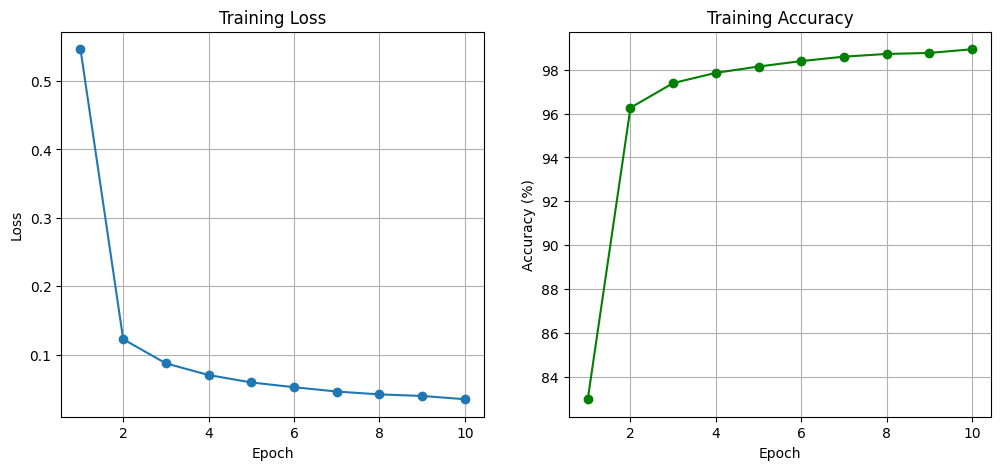


Test Accuracy: 98.09%


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ===============================
# 1. Load dataset MNIST
# ===============================

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# ===============================
# 2. Define CNN model (thêm conv3)
# ===============================

class MNIST_CNN(nn.Module):

    def __init__(self):
        super(MNIST_CNN, self).__init__()

        self.conv1 = nn.Conv2d(1,16,kernel_size=3)
        self.conv2 = nn.Conv2d(16,32,kernel_size=3)

        # Tầng tích chập thứ 3
        self.conv3 = nn.Conv2d(32,64,kernel_size=3)

        self.pool = nn.MaxPool2d(2,2)

        # Sau conv3 + pooling → 64x1x1
        self.fc1 = nn.Linear(64*1*1,10)

    def forward(self,x):

        x = self.pool(torch.relu(self.conv1(x)))

        x = self.pool(torch.relu(self.conv2(x)))

        x = self.pool(torch.relu(self.conv3(x)))

        x = x.view(-1,64*1*1)

        x = self.fc1(x)

        return x


# ===============================
# 3. Initialize model
# ===============================

model = MNIST_CNN()

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(),lr=0.01,momentum=0.9)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

# ===============================
# 4. Training (10 epoch)
# ===============================

loss_values=[]
accuracy_values=[]

for epoch in range(10):

    running_loss=0.0
    correct=0
    total=0

    for images,labels in train_loader:

        images=images.to(device)
        labels=labels.to(device)

        optimizer.zero_grad()

        outputs=model(images)

        loss=criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss+=loss.item()

        _,predicted=torch.max(outputs.data,1)

        total+=labels.size(0)

        correct+=(predicted==labels).sum().item()

    epoch_loss=running_loss/len(train_loader)

    epoch_accuracy=100*correct/total

    loss_values.append(epoch_loss)
    accuracy_values.append(epoch_accuracy)

    print(f"Epoch {epoch+1}/10  Loss:{epoch_loss:.4f}  Accuracy:{epoch_accuracy:.2f}%")

# ===============================
# 5. Plot Loss & Accuracy
# ===============================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1,11),loss_values,marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(range(1,11),accuracy_values,marker='o',color='green')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.show()

# ===============================
# 6. Test model
# ===============================

correct=0
total=0

with torch.no_grad():

    for images,labels in test_loader:

        images=images.to(device)
        labels=labels.to(device)

        outputs=model(images)

        _,predicted=torch.max(outputs.data,1)

        total+=labels.size(0)

        correct+=(predicted==labels).sum().item()

print(f"\nTest Accuracy: {100*correct/total:.2f}%")

Tác dụng của việc thêm tầng tích chập
Việc thêm tầng tích chập giúp mô hình:
trích xuất đặc trưng phức tạp hơn
học được pattern sâu hơn của hình ảnh
cải thiện khả năng phân loại

Các tầng convolution đầu thường học:
edge
stroke
Các tầng sâu hơn học:
shape
pattern phức tạp

Nhờ đó mô hình có thể dự đoán chính xác hơn.

Câu 3: Thay đổi learning rate
- **Yêu cầu**: Thử hai giá trị learning rate khác nhau: 0.001 và 0.1 (thay vì 0.01 ban đầu).
- **Hướng dẫn**: Tìm dòng `optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)` và thay `lr=0.001` rồi `lr=0.1`. Chạy lại code với từng giá trị và ghi nhận:
  - Độ chính xác trên tập test với mỗi learning rate.
  - Biểu đồ mất mát thay đổi ra sao? (Ví dụ: dao động mạnh, giảm chậm, hoặc không hội tụ).
- Cách learning rate ảnh hưởng đến quá trình học của mô hình như thế nào?

LR=0.001  Epoch 1 Loss: 1.8780
LR=0.001  Epoch 2 Loss: 0.4467
LR=0.001  Epoch 3 Loss: 0.2579
LR=0.001  Epoch 4 Loss: 0.2003
LR=0.001  Epoch 5 Loss: 0.1734
LR=0.001  Epoch 6 Loss: 0.1506
LR=0.001  Epoch 7 Loss: 0.1365
LR=0.001  Epoch 8 Loss: 0.1259
LR=0.001  Epoch 9 Loss: 0.1166
LR=0.001  Epoch 10 Loss: 0.1086
Test Accuracy (lr=0.001): 97.06%

LR=0.1  Epoch 1 Loss: 0.3636
LR=0.1  Epoch 2 Loss: 0.1360
LR=0.1  Epoch 3 Loss: 0.1236
LR=0.1  Epoch 4 Loss: 0.1130
LR=0.1  Epoch 5 Loss: 0.1094
LR=0.1  Epoch 6 Loss: 0.1141
LR=0.1  Epoch 7 Loss: 0.1045
LR=0.1  Epoch 8 Loss: 0.1077
LR=0.1  Epoch 9 Loss: 0.0965
LR=0.1  Epoch 10 Loss: 0.0927
Test Accuracy (lr=0.1): 97.65%



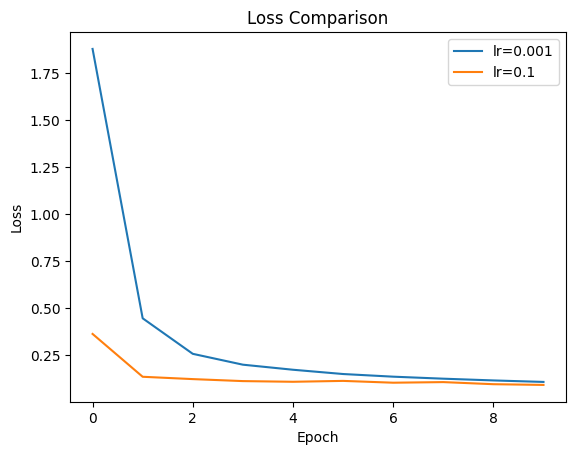

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# =========================
# Load MNIST
# =========================

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# =========================
# CNN Model
# =========================

class MNIST_CNN(nn.Module):

    def __init__(self):
        super(MNIST_CNN,self).__init__()

        self.conv1 = nn.Conv2d(1,16,3)
        self.conv2 = nn.Conv2d(16,32,3)
        self.conv3 = nn.Conv2d(32,64,3)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*1*1,10)

    def forward(self,x):

        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))

        x = x.view(-1,64*1*1)

        x = self.fc1(x)

        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# Function train model
# =========================

def train_model(lr):

    model = MNIST_CNN().to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    loss_values = []

    for epoch in range(10):

        running_loss = 0

        for images,labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        loss_values.append(epoch_loss)

        print(f"LR={lr}  Epoch {epoch+1} Loss: {epoch_loss:.4f}")

    # Test accuracy
    correct = 0
    total = 0

    with torch.no_grad():

        for images,labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _,predicted = torch.max(outputs.data,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Test Accuracy (lr={lr}): {accuracy:.2f}%\n")

    return loss_values, accuracy


# =========================
# Run experiments
# =========================

loss_lr001, acc_lr001 = train_model(0.001)

loss_lr01, acc_lr01 = train_model(0.1)

# =========================
# Plot loss comparison
# =========================

plt.plot(loss_lr001,label="lr=0.001")
plt.plot(loss_lr01,label="lr=0.1")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()

plt.show()

Nhận xét:

0.001: học chậm nhưng ổn định
0.1: học nhanh nhưng dễ dao động  

Biểu đồ Loss thay đổi như thế nào
Learning rate = 0.001
Loss thường:
giảm chậm
↓
giảm đều
↓
ổn định
Điều này cho thấy mô hình học ổn định nhưng chậm.
Learning rate = 0.1
Loss có thể:
dao động mạnh
↑ ↓ ↑ ↓
hoặc:
không giảm ổn định
Điều này xảy ra vì bước cập nhật trọng số quá lớn.

Learning Rate quyết định kích thước bước cập nhật trọng số trong quá trình training.
Learning rate quá nhỏ
model học rất chậm
cần nhiều epoch
→ training ổn định nhưng lâu.
Learning rate phù hợp
loss giảm nhanh
model hội tụ tốt
Learning rate quá lớn
loss dao động
model khó hội tụ
→ kết quả không ổn định.

### Câu 4: Vẽ thêm feature map từ tầng tích chập thứ hai
- **Yêu cầu**: Sửa hàm `visualize_feature_map` để vẽ thêm hai feature map từ tầng `conv2`.
- **Hướng dẫn**:
  - Trong hàm `visualize_feature_map`, thêm dòng `conv2_output = torch.relu(self.conv2(self.pool(torch.relu(self.conv1(img)))))` để tính feature map từ `conv2`.
  - Tăng khung hình từ 3 cột thành 5 cột: `plt.figure(figsize=(20, 4))` và sửa các subplot thành `plt.subplot(1, 5, ...)`.
  - Thêm hai subplot để vẽ `conv2_output[0, 0]` và `conv2_output[0, 1]` (tương tự như `conv1_output`).
  - Chạy lại và mô tả sự khác biệt giữa feature map từ `conv1` và `conv2` (ví dụ: chi tiết hơn, trừu tượng hơn).
- Viết ngắn gọn về sự khác biệt giữa feature map từ các tầng khác nhau.


Epoch 1, Loss: 0.5027, Accuracy: 84.10%
Epoch 2, Loss: 0.1184, Accuracy: 96.35%
Epoch 3, Loss: 0.0827, Accuracy: 97.49%
Epoch 4, Loss: 0.0697, Accuracy: 97.89%
Epoch 5, Loss: 0.0582, Accuracy: 98.21%
Epoch 6, Loss: 0.0510, Accuracy: 98.40%
Epoch 7, Loss: 0.0460, Accuracy: 98.55%
Epoch 8, Loss: 0.0404, Accuracy: 98.70%
Epoch 9, Loss: 0.0361, Accuracy: 98.89%
Epoch 10, Loss: 0.0338, Accuracy: 98.95%

Test Accuracy: 98.45%


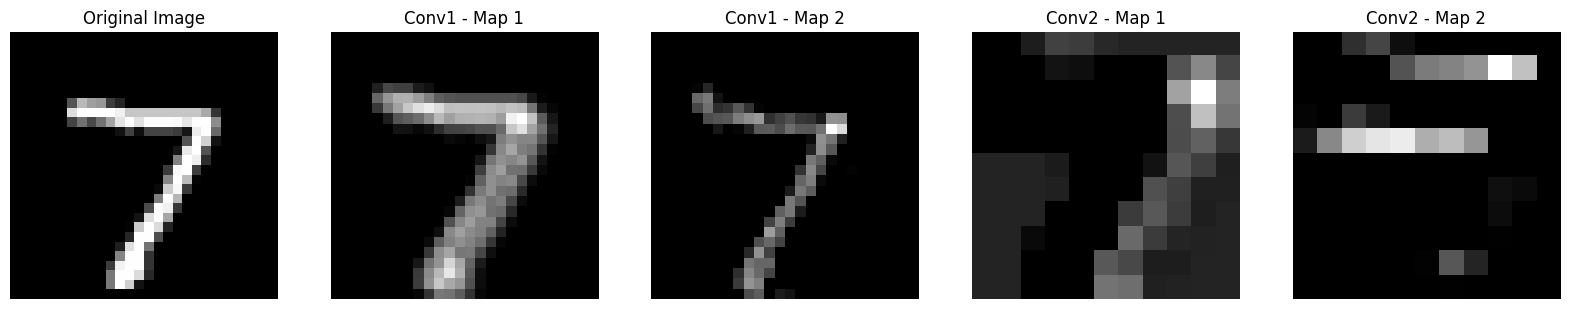

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ===============================
# 1. Load dataset MNIST
# ===============================

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# ===============================
# 2. Define CNN model
# ===============================

class MNIST_CNN(nn.Module):

    def __init__(self):
        super(MNIST_CNN, self).__init__()

        self.conv1 = nn.Conv2d(1,16,kernel_size=3)
        self.conv2 = nn.Conv2d(16,32,kernel_size=3)
        self.conv3 = nn.Conv2d(32,64,kernel_size=3)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*1*1,10)

    def forward(self,x):

        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))

        x = x.view(-1,64*1*1)

        x = self.fc1(x)

        return x


# ===============================
# 3. Initialize model
# ===============================

model = MNIST_CNN()

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)


# ===============================
# 4. Training model
# ===============================

loss_values = []
accuracy_values = []

for epoch in range(10):

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    loss_values.append(epoch_loss)
    accuracy_values.append(epoch_accuracy)

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")


# ===============================
# 5. Test model
# ===============================

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs.data,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

print(f"\nTest Accuracy: {100*correct/total:.2f}%")

# ===============================
# 6. Visualize Feature Maps
# ===============================

def visualize_feature_map():

    model.eval()

    images, _ = next(iter(test_loader))

    img = images[0].unsqueeze(0).to(device)

    # Feature map từ conv1
    conv1_output = torch.relu(model.conv1(img))

    # Feature map từ conv2
    conv2_output = torch.relu(
        model.conv2(
            model.pool(conv1_output)
        )
    )

    plt.figure(figsize=(20,4))

    # Ảnh gốc
    plt.subplot(1,5,1)
    plt.title("Original Image")
    plt.imshow(img.cpu().squeeze(), cmap='gray')
    plt.axis('off')

    # Feature map conv1
    plt.subplot(1,5,2)
    plt.title("Conv1 - Map 1")
    plt.imshow(conv1_output[0,0].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')

    plt.subplot(1,5,3)
    plt.title("Conv1 - Map 2")
    plt.imshow(conv1_output[0,1].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')

    # Feature map conv2
    plt.subplot(1,5,4)
    plt.title("Conv2 - Map 1")
    plt.imshow(conv2_output[0,0].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')

    plt.subplot(1,5,5)
    plt.title("Conv2 - Map 2")
    plt.imshow(conv2_output[0,1].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')

    plt.show()


visualize_feature_map()

Các tầng convolution trong CNN học đặc trưng theo từng mức độ:

Conv1 → đặc trưng cơ bản (edge, stroke)

Conv2 → đặc trưng phức tạp hơn (shape, pattern)

Conv3 → đặc trưng trừu tượng hơn

Nhờ vậy mô hình CNN có thể hiểu cấu trúc của hình ảnh và phân loại chính xác hơn.